# Import thư viện

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_style("whitegrid")

In [2]:
# ============================================================
# THIẾT LẬP KIỂU DÁNG TOÀN CỤC
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

def set_report_style():
    """Áp dụng kiểu định dạng thống nhất, sẵn sàng cho báo cáo cho tất cả biểu đồ"""
    sns.set_theme(style="whitegrid")  # Thiết lập theme nền trắng có lưới
    
    # Bảng màu tùy chỉnh: Xanh dương (chính), Cam (nhấn), Xanh lá, Tím, Vàng, Đỏ
    custom_palette = ["#1A5276", "#E67E22", "#27AE60", "#8E44AD", "#F1C40F", "#E74C3C"]
    sns.set_palette(custom_palette)  # Áp dụng bảng màu
    
    plt.rcParams.update({
        "figure.figsize": (14, 6),      # Kích thước hình
        "figure.dpi": 150,              # Độ phân giải
        "font.family": "sans-serif",    # Font chữ không chân
        "font.size": 12,                # Kích thước font mặc định
        "axes.titlesize": 18,           # Kích thước tiêu đề
        "axes.titleweight": "bold",     # Tiêu đề in đậm
        "axes.titlepad": 20,            # Khoảng cách tiêu đề
        "axes.labelsize": 13,           # Kích thước nhãn trục
        "axes.labelweight": "medium",   # Độ đậm nhãn trục
        "axes.labelpad": 10,            # Khoảng cách nhãn trục
        "axes.grid": True,              # Hiển thị lưới
        "axes.grid.axis": "y",          # Chỉ hiển thị lưới theo trục y
        "grid.alpha": 0.5,              # Độ mờ của lưới
        "grid.linestyle": "--",         # Kiểu đường lưới nét đứt
        "axes.spines.top": False,       # Ẩn viền trên
        "axes.spines.right": False,     # Ẩn viền bên phải
        "xtick.labelsize": 11,          # Kích thước chữ trục x
        "ytick.labelsize": 11,          # Kích thước chữ trục y
        "legend.fontsize": 11,          # Kích thước chữ chú thích (legend)
        "legend.title_fontsize": 12,    # Kích thước tiêu đề legend
        "legend.frameon": False         # Tắt khung của legend
    })

# Áp dụng style toàn cục
set_report_style()

# LOAD DATA

In [3]:
PATH = Path(r"C:\Users\ADMIN\Downloads\DATATHON\DATA")

customers   = pd.read_csv(PATH / "customers.csv")
geography   = pd.read_csv(PATH / "geography.csv")
inventory   = pd.read_csv(PATH / "inventory.csv")
order_items = pd.read_csv(PATH / "order_items.csv")
orders      = pd.read_csv(PATH / "orders.csv")
payments    = pd.read_csv(PATH / "payments.csv")
products    = pd.read_csv(PATH / "products.csv")
promotions  = pd.read_csv(PATH / "promotions.csv")
returns     = pd.read_csv(PATH / "returns.csv")
reviews     = pd.read_csv(PATH / "reviews.csv")
sales       = pd.read_csv(PATH / "sales.csv")
shipments   = pd.read_csv(PATH / "shipments.csv")
web         = pd.read_csv(PATH / "web_traffic.csv")

# Chuyển Date format

In [4]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
returns["return_date"] = pd.to_datetime(returns["return_date"])
reviews["review_date"] = pd.to_datetime(reviews["review_date"])
sales["Date"] = pd.to_datetime(sales["Date"])
shipments["ship_date"] = pd.to_datetime(shipments["ship_date"])
shipments["delivery_date"] = pd.to_datetime(shipments["delivery_date"])
inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])
web["date"] = pd.to_datetime(web["date"])

# Data Audit

In [5]:
# Xem số lượng dòng và cột của mỗi DataFrame
for name, df in {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "products": products,
    "returns": returns,
    "reviews": reviews,
    "sales": sales,
    "shipments": shipments,
    "inventory": inventory,
    "web": web,
    "promotions": promotions,
    "payments": payments,
    "geography": geography,
}.items():
    print(name, df.shape)

orders (646945, 8)
order_items (714669, 7)
customers (121930, 7)
products (2412, 8)
returns (39939, 7)
reviews (113551, 7)
sales (3833, 3)
shipments (566067, 4)
inventory (60247, 17)
web (3652, 7)
promotions (50, 10)
payments (646945, 4)
geography (39948, 4)


In [6]:
# Null check
print("Orders:")
print(orders.isnull().sum())
print("Customers:")
print(customers.isnull().sum())
print("Order Items:")
print(order_items.isnull().sum())
print("Products:")
print(products.isnull().sum())
print("Returns:")
print(returns.isnull().sum())
print("Reviews:")
print(reviews.isnull().sum())
print("Sales:")
print(sales.isnull().sum())
print("Shipments:")
print(shipments.isnull().sum())
print("Inventory:")
print(inventory.isnull().sum())
print("Web:")
print(web.isnull().sum())
print("Promotions:")
print(promotions.isnull().sum())
print("Payments:")
print(payments.isnull().sum())
print("Geography:")
print(geography.isnull().sum())


Orders:
order_id          0
order_date        0
customer_id       0
zip               0
order_status      0
payment_method    0
device_type       0
order_source      0
dtype: int64
Customers:
customer_id            0
zip                    0
city                   0
signup_date            0
gender                 0
age_group              0
acquisition_channel    0
dtype: int64
Order Items:
order_id                0
product_id              0
quantity                0
unit_price              0
discount_amount         0
promo_id           438353
promo_id_2         714463
dtype: int64
Products:
product_id      0
product_name    0
category        0
segment         0
size            0
color           0
price           0
cogs            0
dtype: int64
Returns:
return_id          0
order_id           0
product_id         0
return_date        0
return_reason      0
return_quantity    0
refund_amount      0
dtype: int64
Reviews:
review_id       0
order_id        0
product_id      0
customer_id  

In [7]:
# Kiểm tra tính trùng lặp
orders["order_id"].duplicated().sum()
customers["customer_id"].duplicated().sum()
products["product_id"].duplicated().sum()
order_items["order_id"].duplicated().sum()
returns["return_id"].duplicated().sum()
reviews["review_id"].duplicated().sum()
web["date"].duplicated().sum()
promotions["promo_id"].duplicated().sum()


np.int64(0)

# Tạo fact table

In [8]:
df = order_items.merge(
    orders, on="order_id", how="left"
).merge(
    products, on="product_id", how="left"
)

In [9]:
df.shape

(714669, 21)

In [10]:
df.head()

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_name,category,segment,size,color,price,cogs
0,1,2400,7,"1,138.22",0.00,NaN,NaN,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,"1,109.26","1,053.80"
1,2,609,7,"10,166.25",0.00,NaN,NaN,2012-07-04,58621,1330,returned,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,426.57","8,987.70"
2,3,396,3,"11,220.33",0.00,NaN,NaN,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,"11,028.43","10,091.01"
3,4,635,5,"10,639.25",0.00,NaN,NaN,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,"10,745.22","9,205.43"
4,6,1935,1,"1,597.84",0.00,NaN,NaN,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,purple,"1,609.91","1,048.70"


# Tính toán các chỉ sổ

In [11]:
df["gross_sales"] = df["quantity"] * df["unit_price"]

df["net_sales"] = df["gross_sales"] - df["discount_amount"]

df["total_cogs"] = df["quantity"] * df["cogs"]

df["profit"] = df["net_sales"] - df["total_cogs"]

# Tổng quan các chỉ số KPI

In [12]:
revenue = df['net_sales'].sum()
orders_n = orders['order_id'].nunique()
customers_n = orders['customer_id'].nunique()
aov = revenue / orders_n
profit = df['profit'].sum()
print({'Revenue':revenue,'Orders':orders_n,'Customers':customers_n,'AOV':aov,'Profit':profit})

{'Revenue': np.float64(15680869265.429995), 'Orders': 646945, 'Customers': 90246, 'AOV': np.float64(24238.334426311347), 'Profit': np.float64(1517418746.302136)}


# Xu hướng doanh thu và lợi nhuận hàng tháng

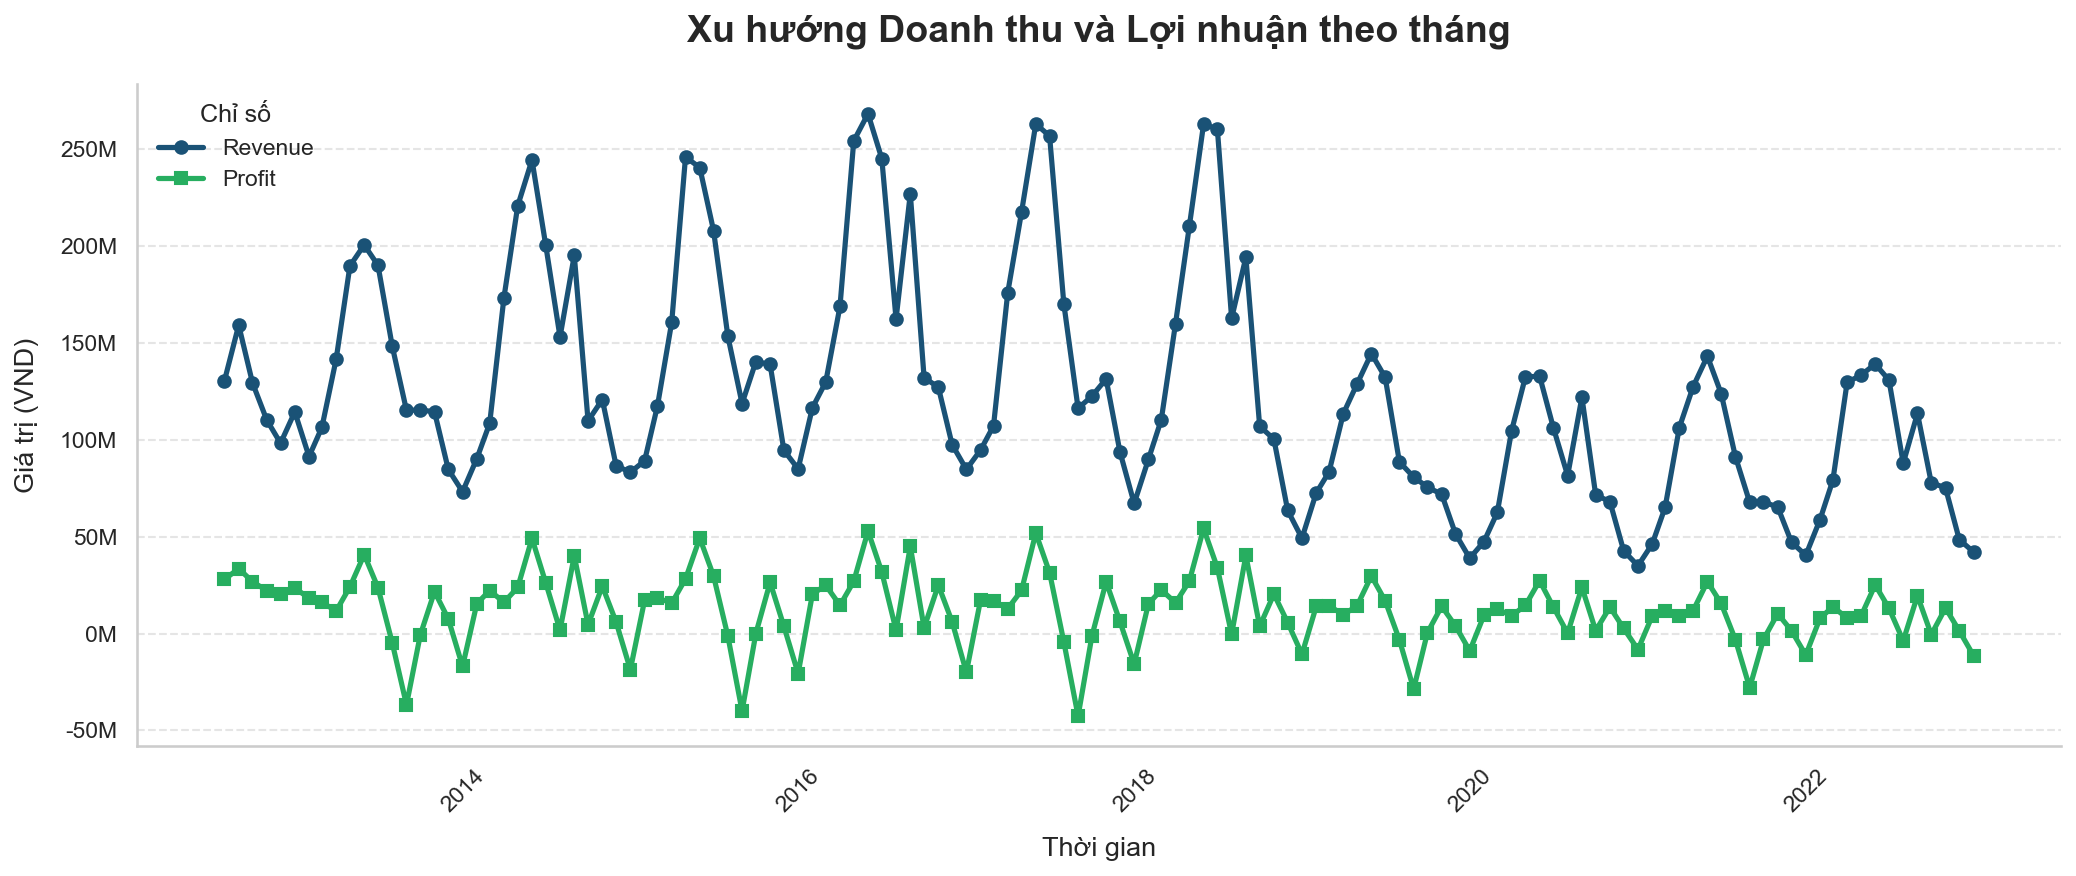

In [13]:
# ============================================================
# BIỂU ĐỒ: Xu hướng Doanh thu & Lợi nhuận
# ============================================================
monthly = df.groupby(pd.Grouper(key='order_date', freq='ME')).agg(
    revenue=('net_sales','sum'),
    profit=('profit','sum'),
    orders=('order_id','nunique')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

# Vẽ 2 đường biểu diễn
ax.plot(monthly['order_date'], monthly['revenue'], 
        marker='o', linewidth=2.5, label='Revenue', color='#1A5276')
ax.plot(monthly['order_date'], monthly['profit'], 
        marker='s', linewidth=2.5, label='Profit', color='#27AE60')

# Định dạng trục Y theo đơn vị triệu
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x/1e6:,.0f}M'))

# Tiêu đề và nhãn trục
ax.set_title('Xu hướng Doanh thu và Lợi nhuận theo tháng', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Thời gian', fontsize=13)
ax.set_ylabel('Giá trị (VND)', fontsize=13)

# Chú thích (legend)
ax.legend(title='Chỉ số', frameon=False, loc='upper left')

# Lưới
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# So sánh Doanh thu, Số đơn và AOV theo thời gian

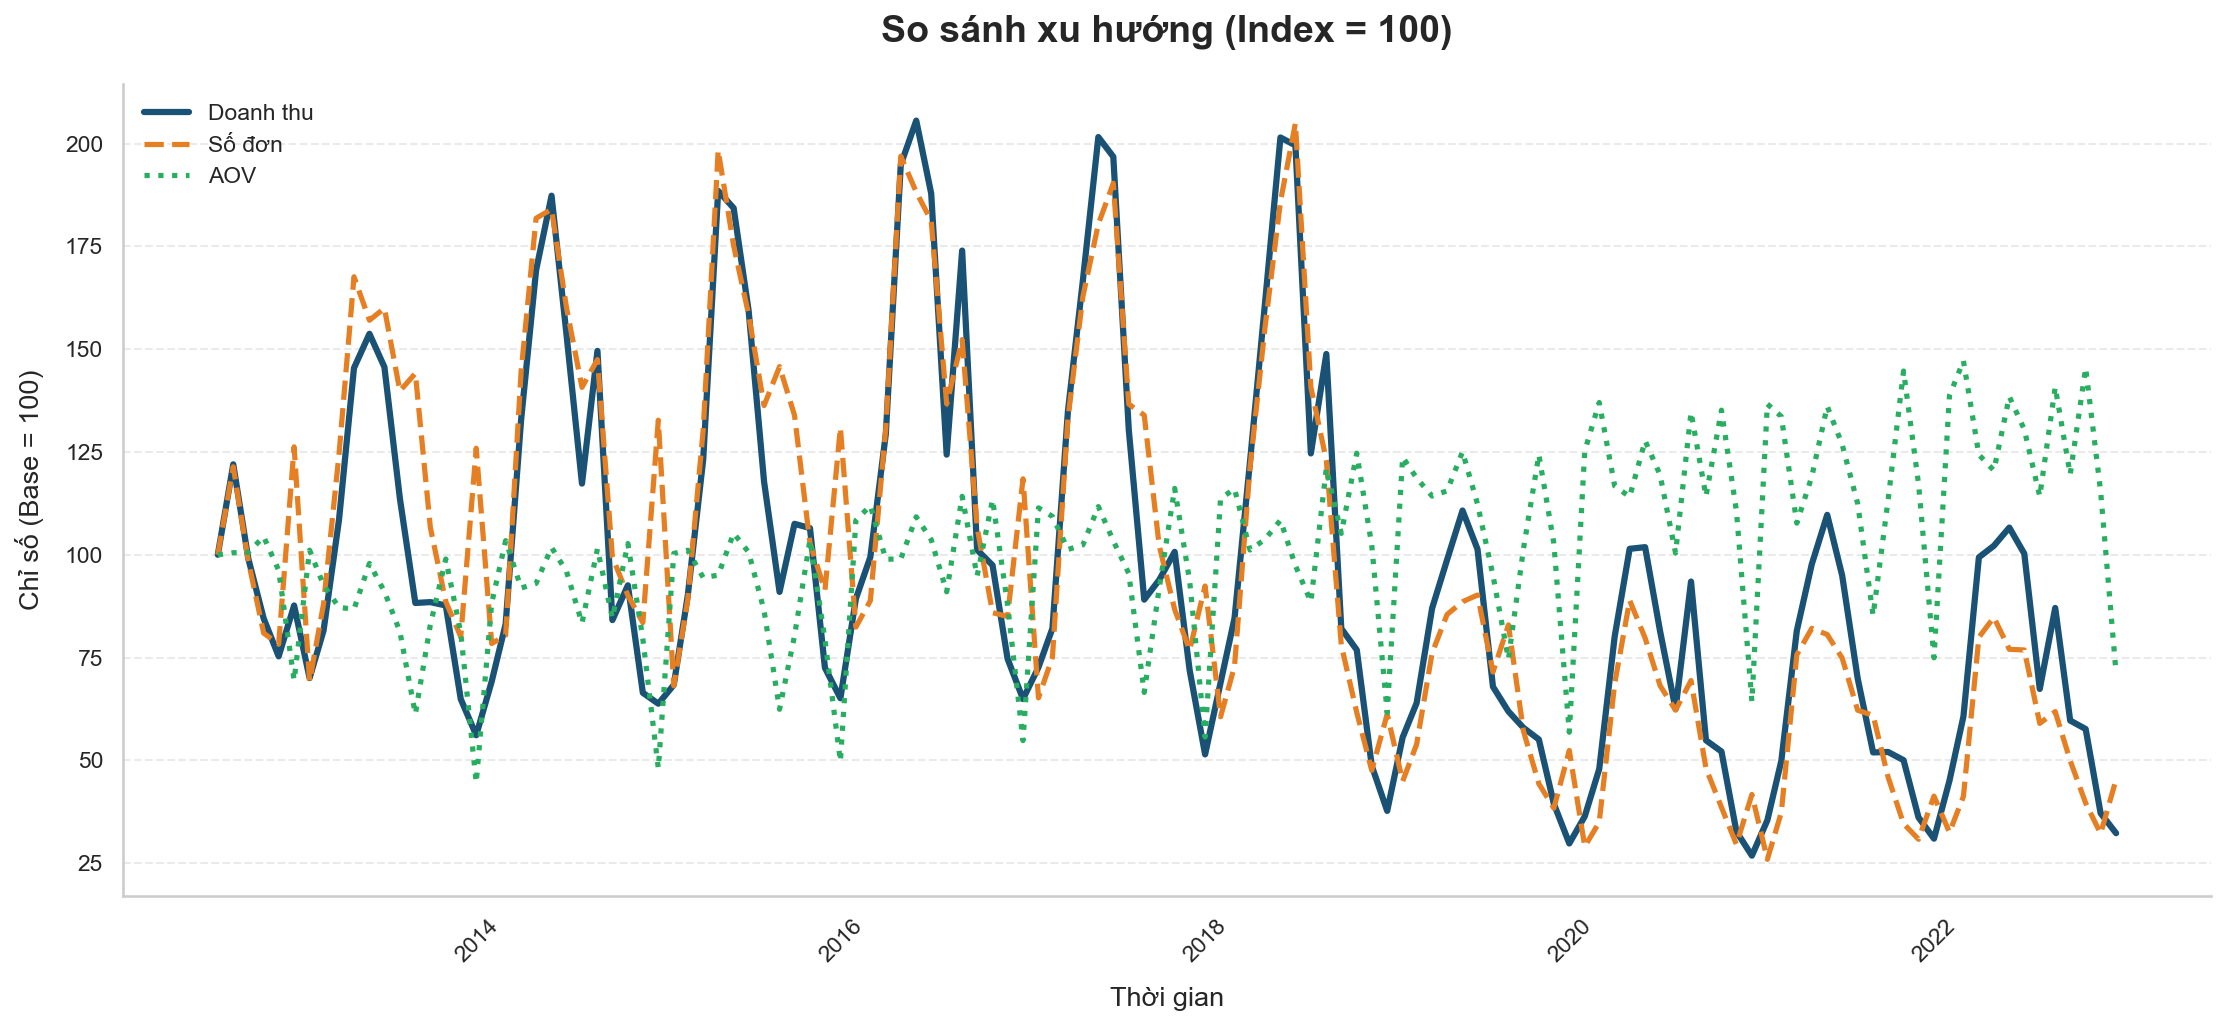

In [35]:
# ============================================================
# CHART: Revenue vs Orders vs AOV
# ============================================================

monthly = df.groupby(pd.Grouper(key='order_date',freq='ME')).agg(
    revenue=('net_sales','sum'),
    orders=('order_id','nunique')
).reset_index()

monthly['AOV'] = monthly['revenue'] / monthly['orders']

# ==================== NORMALIZE (BASE = 100) ====================
monthly['rev_index'] = monthly['revenue'] / monthly['revenue'].iloc[0] * 100
monthly['orders_index'] = monthly['orders'] / monthly['orders'].iloc[0] * 100
monthly['aov_index'] = monthly['AOV'] / monthly['AOV'].iloc[0] * 100

# ==================== PLOT ====================
fig, ax = plt.subplots(figsize=(15,7))

ax.plot(monthly['order_date'], monthly['rev_index'],
        linewidth=3, color='#1A5276', label='Doanh thu')

ax.plot(monthly['order_date'], monthly['orders_index'],
        linewidth=2.5, linestyle='--', color='#E67E22', label='Số đơn')

ax.plot(monthly['order_date'], monthly['aov_index'],
        linewidth=2.5, linestyle=':', color='#27AE60', label='AOV')

# ==================== FORMAT ====================
ax.set_title('So sánh xu hướng (Index = 100)', fontsize=18, fontweight='bold', pad=20)

ax.set_ylabel('Chỉ số (Base = 100)', fontsize=13)
ax.set_xlabel('Thời gian', fontsize=13)

ax.legend(frameon=False, loc='upper left')

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Hiệu suất sản phẩm / danh mục #
Xem category nào tạo doanh thu cao nhất.

                     revenue           profit      qty
category                                              
Streetwear 12,558,477,099.17 1,165,807,511.55  1768826
Outdoor     2,353,396,796.86   267,034,092.02  1170000
Casual        440,285,193.75    33,740,765.23   107469
GenZ          328,710,175.65    50,836,377.50   166848


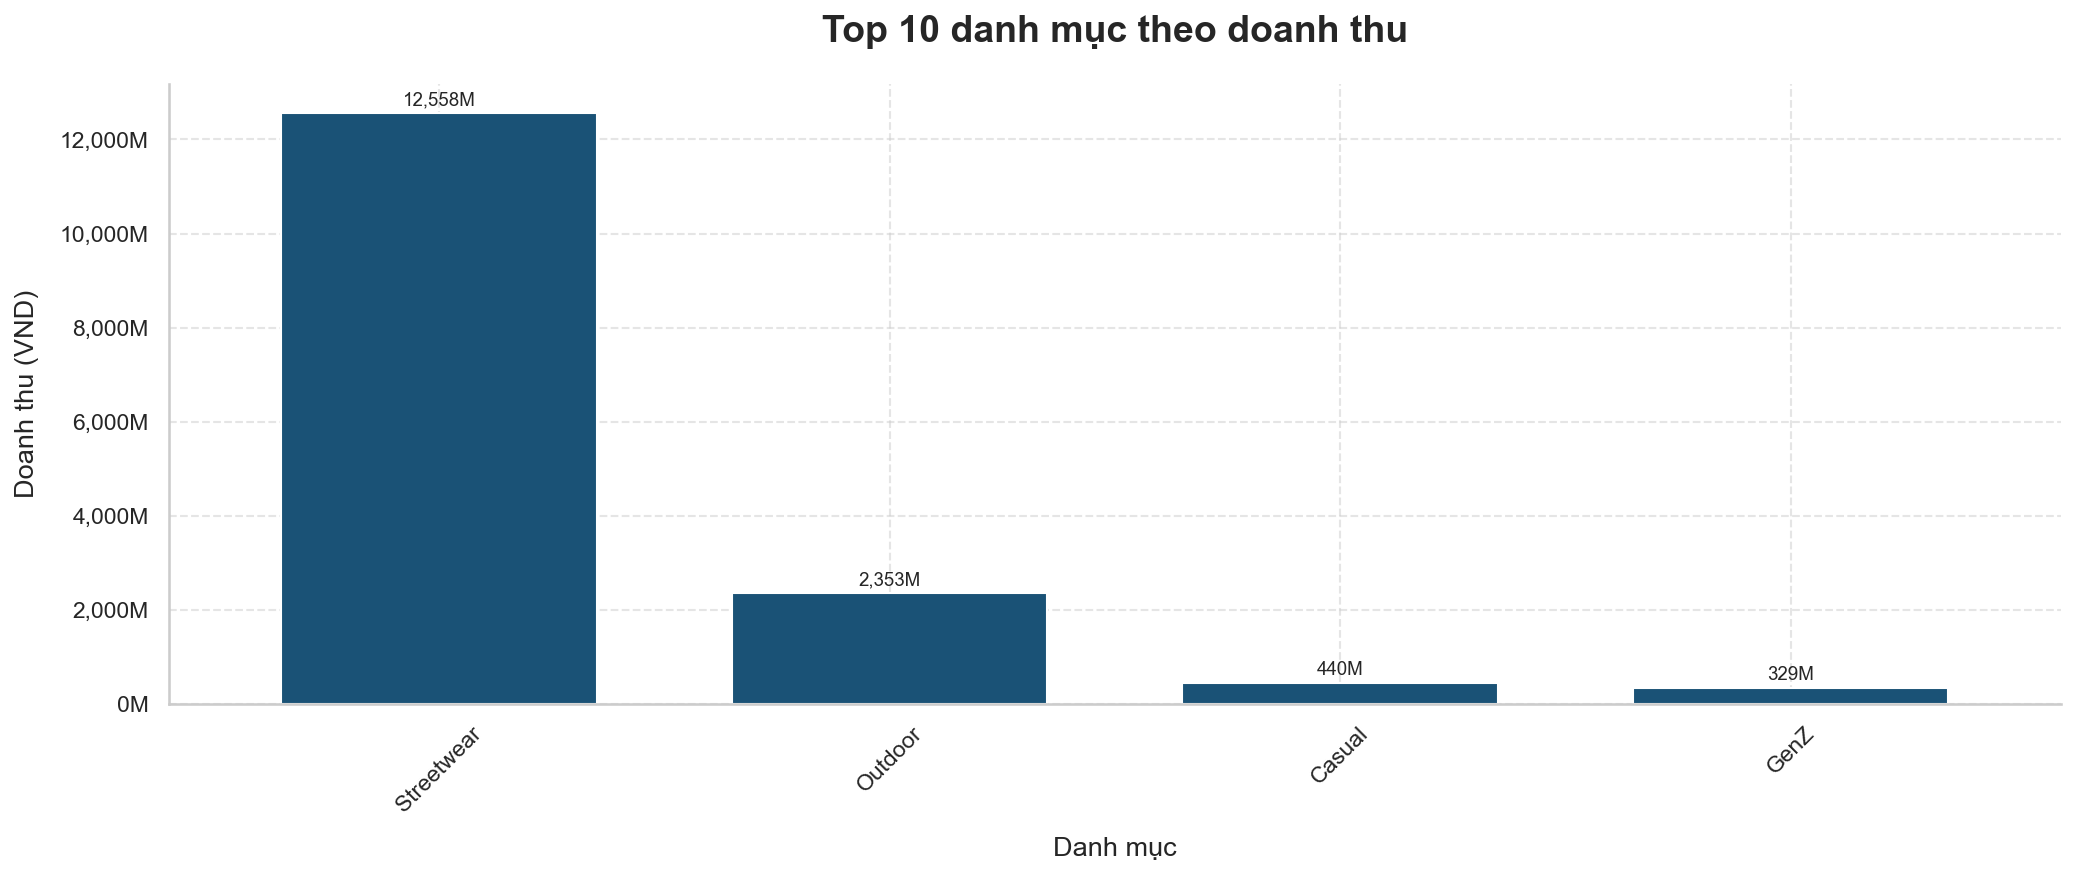

In [18]:
# ============================================================
# BIỂU ĐỒ: Doanh thu theo danh mục
# ============================================================
cat = df.groupby('category').agg(
    revenue=('net_sales','sum'),
    profit=('profit','sum'),
    qty=('quantity','sum')
).sort_values('revenue', ascending=False)

print(cat.head(10))

fig, ax = plt.subplots(figsize=(14, 6))

# Biểu đồ cột kèm nhãn dữ liệu
cat['revenue'].head(10).plot(kind='bar', ax=ax, color='#1A5276', width=0.7)

# Định dạng trục Y theo đơn vị triệu
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x/1e6:,.0f}M'))

# Tiêu đề và nhãn trục
ax.set_title('Top 10 danh mục theo doanh thu', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Danh mục', fontsize=13)
ax.set_ylabel('Doanh thu (VND)', fontsize=13)

# Thêm nhãn giá trị trên cột
for container in ax.containers:
    labels = [f'{v/1e6:,.0f}M' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2, fontsize=9)

# Định dạng trục X
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Xu hướng khách hàng mới và khách hàng quay lại

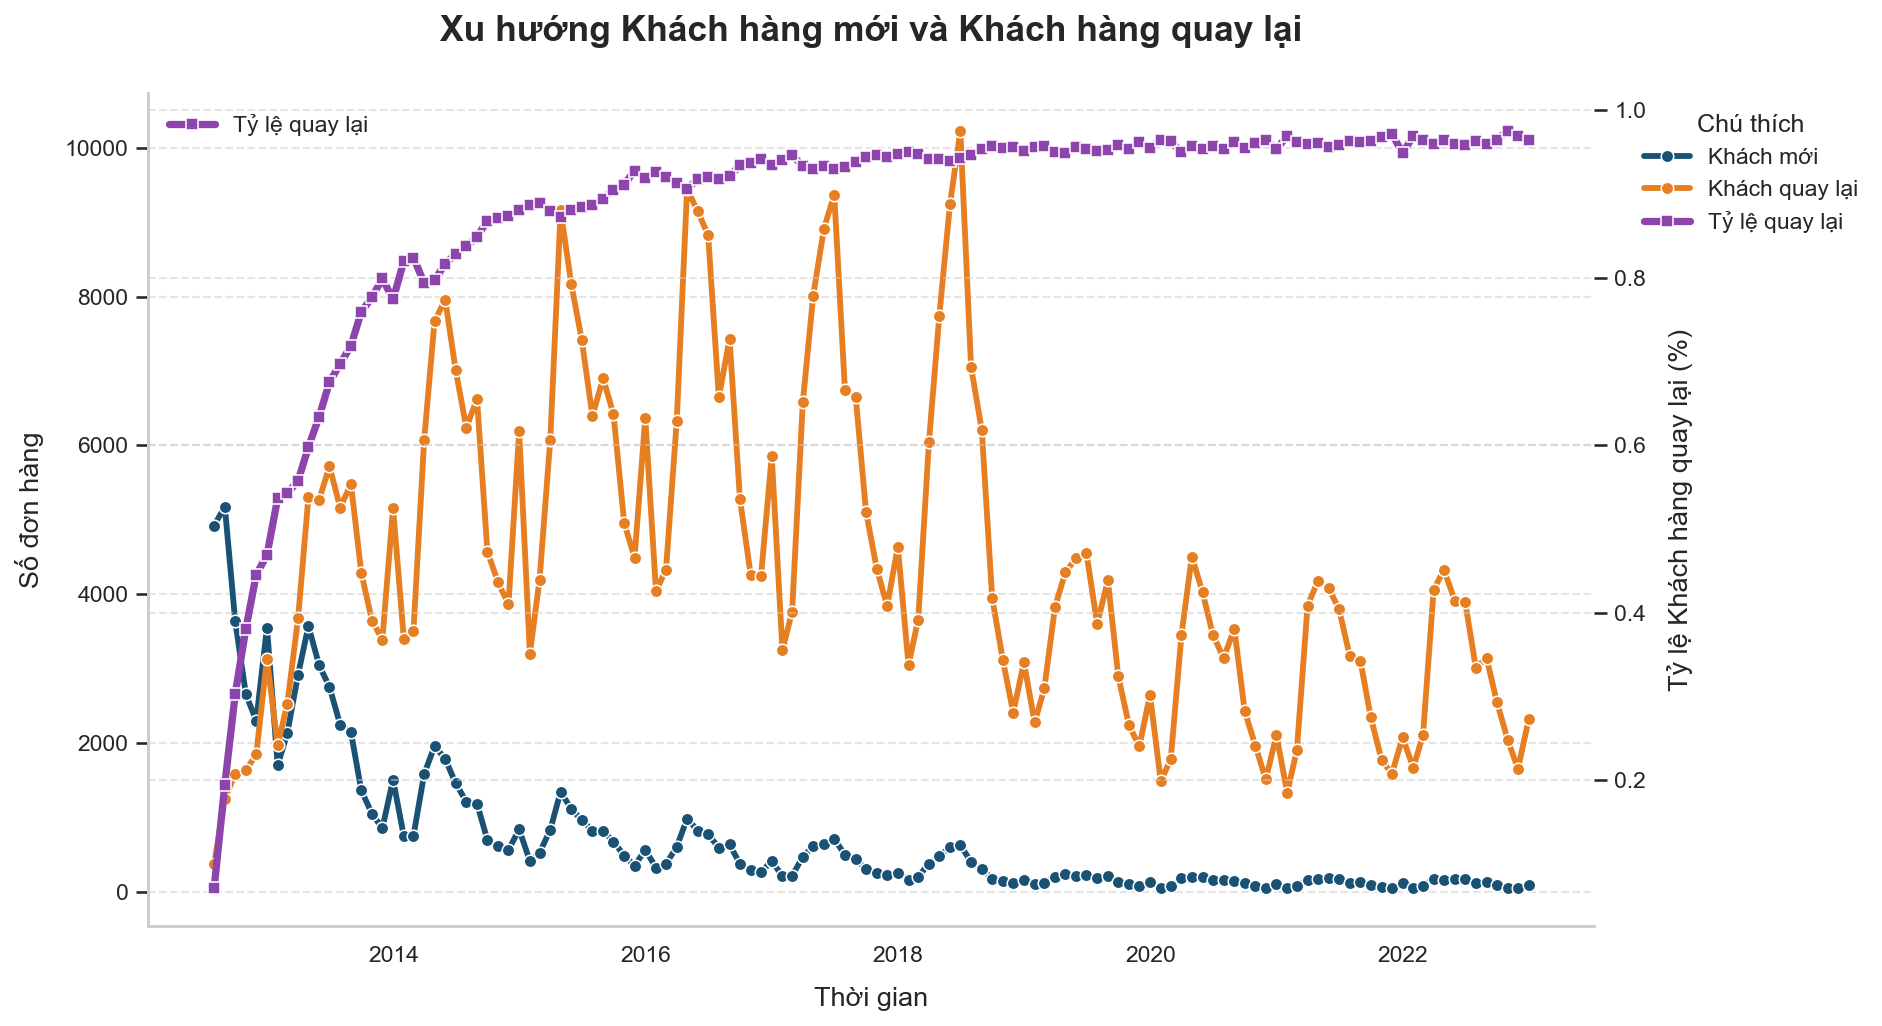

In [27]:
# KHÁCH MỚI VS KHÁCH QUAY LẠI
first_order = orders.groupby('customer_id')['order_date'].min().reset_index(name='first_order_date')
cust = orders.merge(first_order, on='customer_id')
cust['customer_type'] = np.where(cust['order_date'] == cust['first_order_date'], 'New', 'Returning')

cust_month = cust.groupby([pd.Grouper(key='order_date', freq='ME'), 'customer_type']).size().reset_index(name='order_count')

# Tính tỷ lệ khách quay lại
monthly_ret = cust_month.pivot(index='order_date', columns='customer_type', values='order_count').fillna(0)
monthly_ret['returning_ratio'] = monthly_ret['Returning'] / (monthly_ret['New'] + monthly_ret['Returning'])

fig, ax1 = plt.subplots(figsize=(15, 7))

# Line New & Returning
sns.lineplot(data=cust_month, x='order_date', y='order_count', hue='customer_type',
             marker='o', linewidth=2.8, 
             palette={"New": "#1A5276", "Returning": "#E67E22"}, ax=ax1)

ax1.set_ylabel('Số đơn hàng', fontsize=13)
ax1.set_xlabel('Thời gian', fontsize=13)

# Trục phụ
ax2 = ax1.twinx()
sns.lineplot(data=monthly_ret, x=monthly_ret.index, y='returning_ratio', 
             color='#8E44AD', linewidth=3.5, marker='s', 
             label='Tỷ lệ quay lại', ax=ax2)

ax2.set_ylabel('Tỷ lệ Khách hàng quay lại (%)', fontsize=13)

# Title
ax1.set_title('Xu hướng Khách hàng mới và Khách hàng quay lại', 
              fontsize=17, fontweight='bold', pad=25)

# ==================== FIX LEGEND ====================
# Lấy handles & labels chuẩn
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Xóa legend cũ
ax1.legend_.remove()

# Legend bên phải (gộp luôn cho sạch)
ax1.legend(handles=handles1 + handles2,
           labels=['Khách mới', 'Khách quay lại', 'Tỷ lệ quay lại'],
           loc='upper left',
           bbox_to_anchor=(1.02, 1),   # đẩy ra ngoài
           frameon=False,
           title='Chú thích')

plt.xticks(rotation=45)

# Quan trọng: chừa chỗ bên phải cho legend
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()

# Lưu lượng truy cập và tỷ lệ chuyển đổi

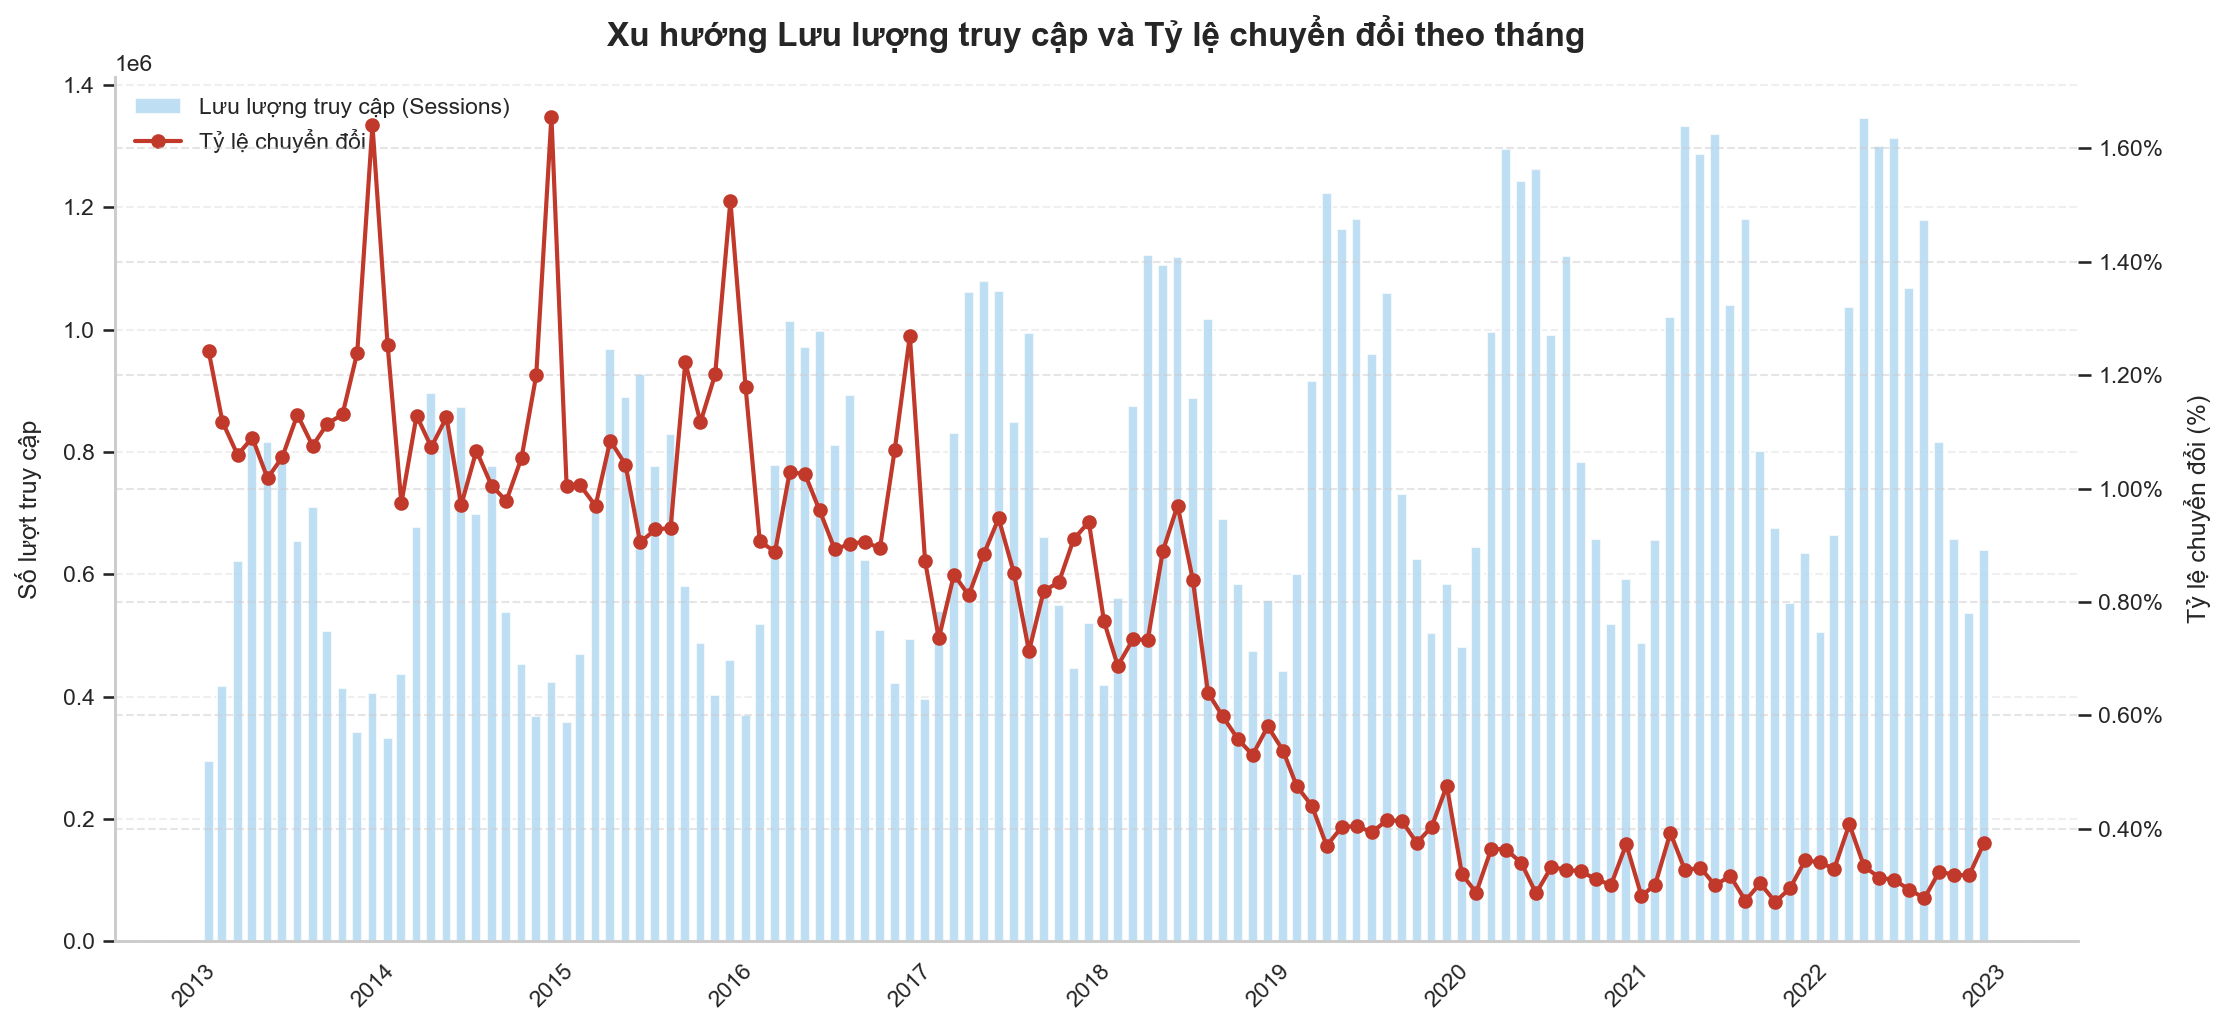

In [28]:
# ============================================================
# BIỂU ĐỒ: Lưu lượng truy cập & Tỷ lệ chuyển đổi theo tháng
# ============================================================

# Giả sử dữ liệu:
# web: gồm cột date, sessions
# orders: gồm cột order_date, order_id

# ==================== XỬ LÝ DỮ LIỆU ====================
web_month = web.groupby(pd.Grouper(key='date', freq='ME')).agg(
    sessions=('sessions', 'sum')
).reset_index()

orders_month = orders.groupby(pd.Grouper(key='order_date', freq='ME')).agg(
    orders=('order_id', 'nunique')
).reset_index()

# Gộp dữ liệu
conv = web_month.merge(orders_month, left_on='date', right_on='order_date', how='left')
conv['orders'] = conv['orders'].fillna(0)

# Tính tỷ lệ chuyển đổi
conv['conversion_rate'] = conv['orders'] / conv['sessions']

# ==================== VẼ BIỂU ĐỒ ====================
fig, ax1 = plt.subplots(figsize=(15,7))

# ===== CỘT: Lưu lượng truy cập =====
ax1.bar(conv['date'], conv['sessions'],
        color='#AED6F1', width=20, alpha=0.8,
        label='Lưu lượng truy cập (Sessions)')

ax1.set_ylabel('Số lượt truy cập', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# ===== ĐƯỜNG: Tỷ lệ chuyển đổi =====
ax2 = ax1.twinx()

ax2.plot(conv['date'], conv['conversion_rate'],
         color='#C0392B', marker='o', linewidth=2,
         label='Tỷ lệ chuyển đổi')

ax2.set_ylabel('Tỷ lệ chuyển đổi (%)', fontsize=12)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# ===== CHÚ THÍCH =====
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', frameon=False)

# ===== TIÊU ĐỀ =====
ax1.set_title('Xu hướng Lưu lượng truy cập và Tỷ lệ chuyển đổi theo tháng',
              fontsize=16, fontweight='bold', pad=15)

# ===== LƯỚI =====
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Phân tích tồn kho 

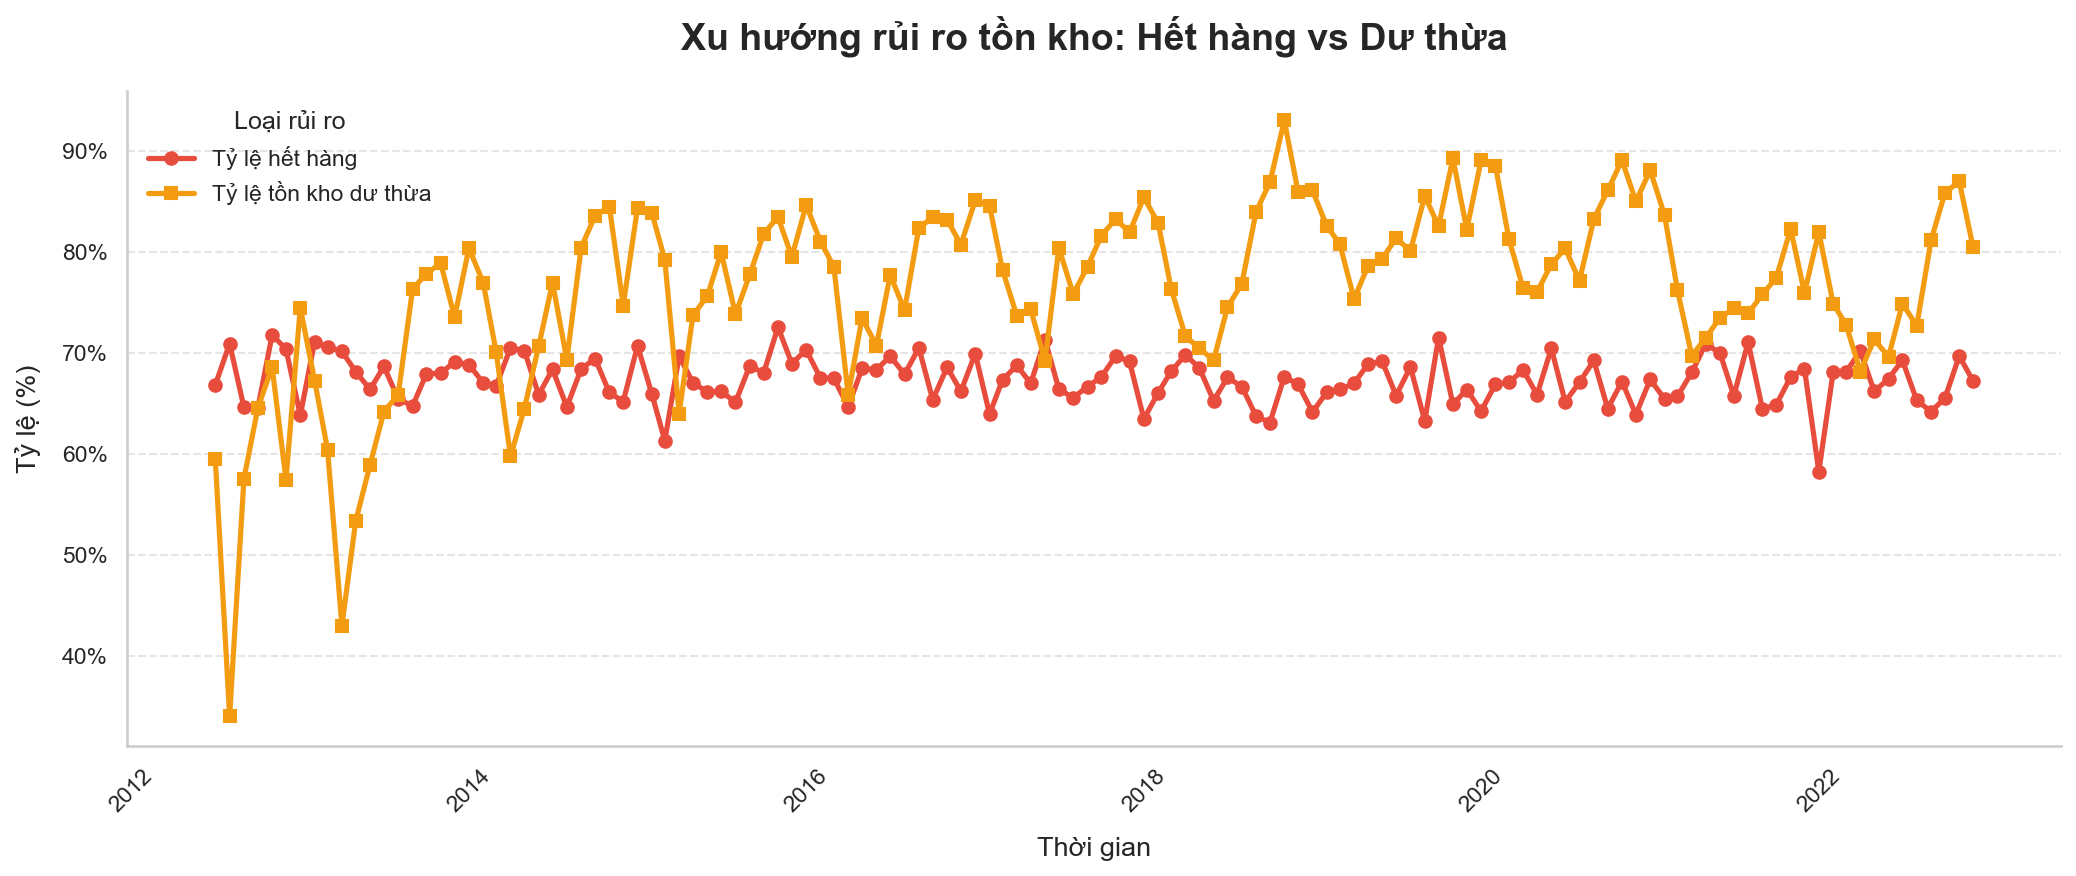

In [30]:
# ============================================================
# BIỂU ĐỒ: Xu hướng rủi ro tồn kho (Hết hàng & Tồn kho dư thừa)
# ============================================================
inv_month = inventory.groupby(['year','month']).agg(
    stockout_rate=('stockout_flag','mean'),
    overstock_rate=('overstock_flag','mean'),
    fill_rate=('fill_rate','mean')
).reset_index()

inv_month['period'] = pd.to_datetime(
    inv_month['year'].astype(str) + '-' + inv_month['month'].astype(str) + '-01'
)

fig, ax = plt.subplots(figsize=(14, 6))

# Biểu đồ đường với màu cảnh báo
ax.plot(inv_month['period'], inv_month['stockout_rate'], 
        marker='o', linewidth=2.5, label='Tỷ lệ hết hàng', color='#E74C3C')

ax.plot(inv_month['period'], inv_month['overstock_rate'], 
        marker='s', linewidth=2.5, label='Tỷ lệ tồn kho dư thừa', color='#F39C12')

# Định dạng trục Y dạng phần trăm
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

# Tiêu đề và nhãn trục
ax.set_title('Xu hướng rủi ro tồn kho: Hết hàng vs Dư thừa', 
             fontsize=18, fontweight='bold', pad=20)

ax.set_xlabel('Thời gian', fontsize=13)
ax.set_ylabel('Tỷ lệ (%)', fontsize=13)

# Chú thích và lưới
ax.legend(title='Loại rủi ro', frameon=False)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Hiệu quả Doanh thu & Biên Lợi nhuận theo loại Khuyến mãi

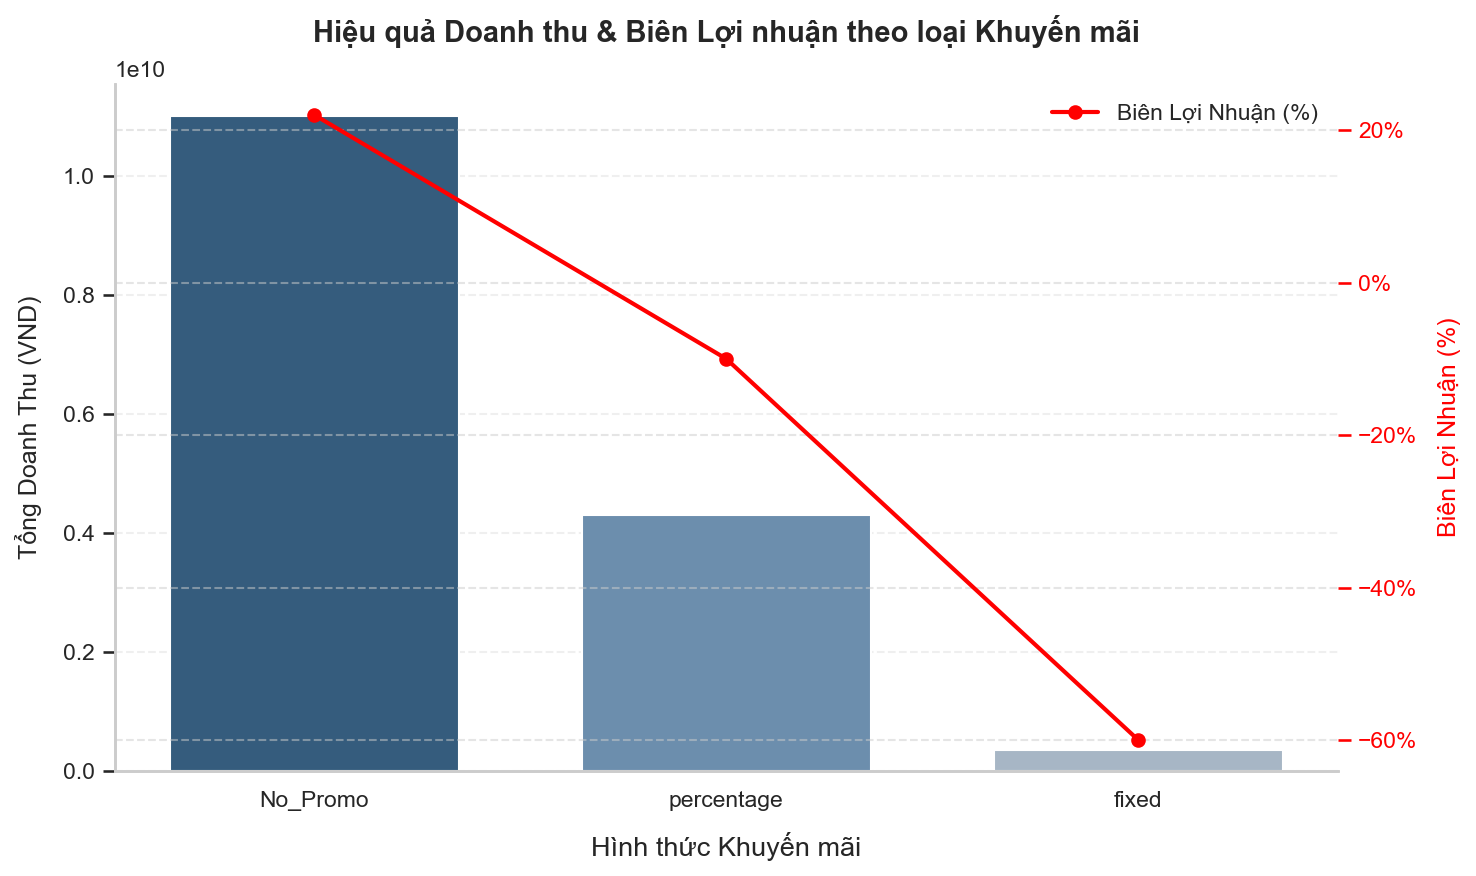

In [31]:
# ============================================================
# BIỂU ĐỒ: Doanh thu & Biên lợi nhuận theo loại khuyến mãi
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ===== DATA (bạn có thể thay bằng data thật) =====
promo_type = ['No_Promo', 'percentage', 'fixed']

revenue = [1.1e10, 4.3e9, 3.5e8]   # Doanh thu (VND)
margin = [0.22, -0.10, -0.60]      # Biên lợi nhuận (% dạng decimal)

# ===== PLOT =====
fig, ax1 = plt.subplots(figsize=(10, 6))

# ===== BAR: DOANH THU =====
bars = ax1.bar(
    promo_type,
    revenue,
    color=['#355C7D', '#6C8EAD', '#A7B6C5'],
    width=0.7
)

ax1.set_ylabel('Tổng Doanh Thu (VND)', fontsize=12)
ax1.tick_params(axis='y')

# ===== LINE: BIÊN LỢI NHUẬN =====
ax2 = ax1.twinx()

ax2.plot(
    promo_type,
    margin,
    color='red',
    marker='o',
    linewidth=2,
    label='Biên Lợi Nhuận (%)'
)

ax2.set_ylabel('Biên Lợi Nhuận (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', colors='red')

# Format % cho trục phải
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# ===== TITLE =====
ax1.set_title('Hiệu quả Doanh thu & Biên Lợi nhuận theo loại Khuyến mãi',
              fontsize=14, fontweight='bold')

# ===== LEGEND =====
ax2.legend(loc='upper right', frameon=False)

# ===== STYLE =====
ax1.set_xlabel('Hình thức Khuyến mãi')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()